In [1]:
%run PAClient.ipynb
%run Logger.ipynb
%run RestTest.ipynb

In [79]:
# run tests before playing with Rest
unittest.main(argv=[''], verbosity=2, exit=False)

test_apply_transformer_content (__main__.TestPA.test_apply_transformer_content) ... ok
test_apply_transformer_doc (__main__.TestPA.test_apply_transformer_doc) ... ok
test_atomic_dbg_img2text (__main__.TestPA.test_atomic_dbg_img2text) ... ERROR
test_atomic_dbg_src (__main__.TestPA.test_atomic_dbg_src) ... ok
test_atomic_dbg_text2image (__main__.TestPA.test_atomic_dbg_text2image) ... ok
test_atomic_dbg_text2text (__main__.TestPA.test_atomic_dbg_text2text) ... ok
test_atomic_openai_text2image (__main__.TestPA.test_atomic_openai_text2image) ... ok
test_atomic_openai_text2text (__main__.TestPA.test_atomic_openai_text2text) ... ok
test_chain_mapping (__main__.TestPA.test_chain_mapping) ... ok
test_complex_chain (__main__.TestPA.test_complex_chain) ... ok
test_create_doc (__main__.TestPA.test_create_doc) ... ok
test_create_feed (__main__.TestPA.test_create_feed) ... ok
test_create_feed_trans_dict (__main__.TestPA.test_create_feed_trans_dict) ... ok
test_create_transformer (__main__.TestPA.tes

In [2]:
from PIL import Image
from pydub import AudioSegment
from pydub.playback import play

/Users/yaroslavm/Documents/promtartvev/lib/python3.11/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [3]:
pac = PAClient(url="https://5ftnewdis2.execute-api.us-east-1.amazonaws.com/test")
log = Logger("debug")

### Content:
* [user](#user)
* [docs](#docs)
* [media docs](#media_docs)
* [transformer](#transformer)
* [simple transformer media](#simple_transformer_media)
* [compose transformer with mapping T(T(T(dbg_text2test), T(openai_text2text)), T(openai_text2text))](#compose_transformer_with_mapping)
* [compose media transformer with mapping T(T(T(openai_text2text), T(openai_text2text)), T(openai_image2text))](#compose_media_transformer_with_mapping)
* [compose transformer T(T(dbg_text2test), T(dbg_text2text))](#compose_transformer1)
* [compose transformer T(T(dbg_text2image), T(dbg_img2text))](#compose_transformer2)
* [compose transformer T(T(T(T(dbg_text2image),T(dbg_image2text)), T(dbg_text2text)), T(dbg_text2image))](#compose_transformer3)
* [compose transformer T(T(T(T(dbg_src), T(dbg_text2text)), T(dbg_text2image), T(dbg_image2text)), T(dbg_text2image))](#compose_transformer4)
* [node](#node)
* [node from src](#node_from_src)

### user <a class="anchor" id="user"></a>

In [6]:
def test_users():
    user=pac.userCreate(name="test_user",balance=100)
    log.debug(f"Created user={user}")
    
    user=pac.userGet(user["uid"])
    log.debug(f"Fetched user={user}")
    
    user=pac.userCredit(user["uid"], 10)
    log.debug(f"Rich user={user}")
    
    users=pac.userEnum(q=f"uid='{user['uid']}'")
    log.debug(f"Filtered users={users}")
    
    user=pac.userDelete(user["uid"])
    log.debug(f"Deleted user={user}")
    
    users=pac.userEnum()
    #log.debug(f"All users={users}")
    
test_users()

DEBUG - Created user={'message': 'Internal server error'}


KeyError: 'uid'

### docs <a class="anchor" id="docs"></a>

In [17]:
def test_docs():
    user=pac.userCreate(name="test_user",balance=100)
    log.debug(f"Created user={user}")
    
    doc=pac.docCreate(content={"ssText":"my prompt"},owner=user['uid'])
    log.debug(f"New doc={doc}")
    
    doc=pac.docUpdate(doc["uid"],status="completed")
    log.debug(f"Updated doc={doc}")
    
    doc=pac.docFormat(doc["uid"])
    log.debug(f"Fetched doc={doc}")
    
    res=pac.docPollForStatus(doc["uid"],status="completed")
    log.debug(f"Poll result={res}")
    
    res=pac.docEnum(q=f"uid='{doc['uid']}'")
    log.debug(f"Filtered docs={res}")
    
    res=pac.docDelete(doc["uid"])
    log.debug(f"Deleted doc={res}")
    
    user=pac.userDelete(user["uid"])
    log.debug(f"Deleted user={user}")
    
    docs=pac.docEnum()
    #log.debug(f"All docs={docs}")
    
test_docs()

DEBUG - Created user={'name': 'test_user', 'balance': 100, 'uid': '4684f180-76f3-45aa-b61c-390bc7792774', 'datecreated': '2023-07-25 15:32:27.957492'}
DEBUG - New doc={'status': 'ready', 'content': {'ssText': 'my prompt'}, 'owner': '4684f180-76f3-45aa-b61c-390bc7792774', 'uid': 'a70494e4-de30-49f0-be8d-ae5cf717efe8', 'datecreated': '2023-07-25 15:32:28.640474'}
DEBUG - Updated doc={'uid': 'a70494e4-de30-49f0-be8d-ae5cf717efe8', 'status': 'completed', 'content': {'ssText': 'my prompt'}, 'parent': None, 'owner': '4684f180-76f3-45aa-b61c-390bc7792774', 'feed': None, 'datecreated': '2023-07-25 15:32:28.640474'}
DEBUG - Fetched doc={'uid': 'a70494e4-de30-49f0-be8d-ae5cf717efe8', 'status': 'completed', 'content': {'ssText': 'my prompt'}, 'parent': None, 'owner': '4684f180-76f3-45aa-b61c-390bc7792774', 'feed': None, 'datecreated': '2023-07-25 15:32:28.640474'}
DEBUG - Poll result=completed
DEBUG - Filtered docs=[{'uid': 'a70494e4-de30-49f0-be8d-ae5cf717efe8'}]
DEBUG - Deleted doc=a70494e4-de3

### media docs

DEBUG - Created user={'name': 'test_user', 'balance': 100, 'uid': '7f11c7d1-cbf6-4428-9255-4ec97cbfc919', 'datecreated': '2023-07-25 15:32:58.697368'}
DEBUG - Created doc with image={'status': 'ready', 'content': {'bjImage': '61f8b19e-b648-4820-88cf-e231ba0cd0e2.jpg'}, 'owner': '7f11c7d1-cbf6-4428-9255-4ec97cbfc919', 'uid': '523cc06e-079e-4551-b7c6-f6c0508a1fd9', 'datecreated': '2023-07-25 15:32:59.776368'}
DEBUG - Displaying media file directly


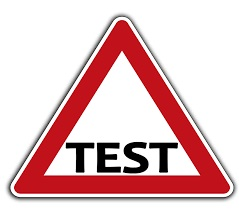

DEBUG - Displaying media file embedded


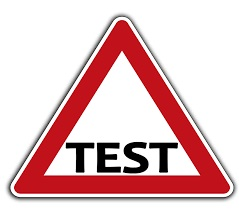

DEBUG - Deleted doc=523cc06e-079e-4551-b7c6-f6c0508a1fd9
DEBUG - Deleted user=7f11c7d1-cbf6-4428-9255-4ec97cbfc919


In [18]:
def test_docimage():
    test_image_path="image2text.jpg"

    user=pac.userCreate(name="test_user",balance=100)
    log.debug(f"Created user={user}")
    
    doc=pac.docCreate(content={"bjImage":file2b64(test_image_path)},owner=user['uid'])
    log.debug(f"Created doc with image={doc}")
    
    media=pac.docMedia(doc['content']['bjImage'])
    log.debug("Displaying media file directly")
    display(Image.open(b642bin(media)))

    doc=pac.docFormat(doc['uid'],fmt="json_base64")
    log.debug("Displaying media file embedded")
    display(Image.open(b642bin(doc['content']['bjImage'])))
    
    res=pac.docDelete(doc["uid"])
    log.debug(f"Deleted doc={res}")
    
    user=pac.userDelete(user["uid"])
    log.debug(f"Deleted user={user}")

test_docimage()

In [19]:
def test_docaudio():
    test_audio_path="speech2Text.mp3"

    user=pac.userCreate(name="test_user",balance=100)
    log.debug(f"Created user={user}")
    
    doc=pac.docCreate(content={"bmAudio":file2b64(test_audio_path)},owner=user['uid'])
    log.debug(f"Created doc with audio={doc}")

    media=pac.docMedia(doc['content']['bmAudio'])
    log.debug("Playing media file directly (code lines are commented)")

    #song=AudioSegment.from_mp3(b642bin(media)) 
    #play(song)
    
    res=pac.docDelete(doc["uid"])
    log.debug(f"Deleted doc={res}")
    
    user=pac.userDelete(user["uid"])
    log.debug(f"Deleted user={user}")

test_docaudio()

DEBUG - Created user={'name': 'test_user', 'balance': 100, 'uid': '951bd2cd-9909-45df-aaa4-6e7724d76bc3', 'datecreated': '2023-07-25 15:33:09.017812'}
DEBUG - Created doc with audio={'status': 'ready', 'content': {'bmAudio': 'e4c8aae6-495d-4507-b444-50d32c9bba14.mp3'}, 'owner': '951bd2cd-9909-45df-aaa4-6e7724d76bc3', 'uid': '2ef0c758-5f82-4117-8d8d-5cb3cb85f821', 'datecreated': '2023-07-25 15:33:10.407525'}
DEBUG - Playing media file directly (code lines are commented)
DEBUG - Deleted doc=2ef0c758-5f82-4117-8d8d-5cb3cb85f821
DEBUG - Deleted user=951bd2cd-9909-45df-aaa4-6e7724d76bc3


### transformer

In [6]:
def test_transformers():
    user=pac.userCreate(name="test_user",balance=100)
    log.debug(f"Created user={user}")
    
    transformer=pac.transformCreate("test", {"chain":"_dbg_text2text"},owner=user['uid'])
    log.debug(f"New transformer={transformer}")
    
    transformer=pac.transformGet(transformer['uid'])
    log.debug(f"Fetched transformer={transformer}")
    
    transformer=pac.transformUpdate(transformer['uid'], fees={"prompt_fees":{user['uid']:5}})
    log.debug(f"Updated transformer={transformer}")
    
    user2=pac.userCreate(name="test_user2",balance=100)
    log.debug(f"Created user={user2}\n")
    
    log.debug(f"Requesting user is {pac.userGet(user2['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user['uid'])}")
    log.debug(f"Applying transformer={transformer['uid']}...")
    doc=pac.transformApply(transformer["uid"],user2['uid'], {"ssText":"sample text"})
    res=pac.docPollForStatus(doc["did"],status="ready")
    log.debug(f"Polling result={res}\n")
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    
    log.debug(f"Requesting user {user2['uid']} expected balance: {95}")
    log.debug(f"Transformer owner {user['uid']} expected balance: {105}")
    
    log.debug(f"Requesting user is {pac.userGet(user2['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user['uid'])}\n")
    
    res=pac.transformEnum()
    #log.debug(f"All available transformers: {res}")
    
    res=pac.transformEnum(q=f"uid='{transformer['uid']}'")
    log.debug(f"Filtered transformers={res}")
    
    res=pac.transformDelete(transformer["uid"])
    log.debug(f"Deleted transformer={res}")
    
    user=pac.userDelete(user["uid"])
    log.debug(f"Deleted user={user}")
    
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    
test_transformers()

DEBUG - Created user={'name': 'test_user', 'balance': 100, 'uid': '0106abff-0bcb-434a-ade7-4ce3f79b1fa6', 'datecreated': '2023-07-26 18:36:47.608258'}
DEBUG - New transformer={'name': 'test', 'cfg': {'chain': '_dbg_text2text'}, 'owner': '0106abff-0bcb-434a-ade7-4ce3f79b1fa6', 'fees': {'process_fees': {}, 'prompt_fees': {}}, 'uid': 'f8fb8e2d-29f1-4982-bc69-c58867a28f08', 'datecreated': '2023-07-26 18:36:48.248312'}
DEBUG - Fetched transformer={'uid': 'f8fb8e2d-29f1-4982-bc69-c58867a28f08', 'cfg': {'chain': '_dbg_text2text'}, 'owner': '0106abff-0bcb-434a-ade7-4ce3f79b1fa6', 'fees': {'process_fees': {}, 'prompt_fees': {}}, 'name': 'test', 'description': None, 'mapio': None, 'datecreated': '2023-07-26 18:36:48.248312'}
DEBUG - Updated transformer={'uid': 'f8fb8e2d-29f1-4982-bc69-c58867a28f08', 'cfg': {'chain': '_dbg_text2text'}, 'owner': '0106abff-0bcb-434a-ade7-4ce3f79b1fa6', 'fees': {'prompt_fees': {'0106abff-0bcb-434a-ade7-4ce3f79b1fa6': 5}}, 'name': 'test', 'description': None, 'mapio'

{'did': '48d3449c-92d4-44a6-9a09-9e24452cccfa'}


DEBUG - Polling result=ready

DEBUG - Resulting document={'uid': '48d3449c-92d4-44a6-9a09-9e24452cccfa', 'status': 'ready', 'content': {'ssText': 'sample text[]'}, 'parent': '17b8df64-f1f1-4682-bd92-cccc8aa62d61', 'owner': '04a8cf41-ea89-4d77-9b58-343d11729480', 'feed': None, 'datecreated': '2023-07-26 18:36:54.294050'}
DEBUG - Requesting user 04a8cf41-ea89-4d77-9b58-343d11729480 expected balance: 95
DEBUG - Transformer owner 0106abff-0bcb-434a-ade7-4ce3f79b1fa6 expected balance: 105
DEBUG - Requesting user is {'uid': '04a8cf41-ea89-4d77-9b58-343d11729480', 'name': 'test_user2', 'balance': 95.0, 'datecreated': '2023-07-26 18:36:50.108252', 'email': None, 'subscription': None}
DEBUG - Transformer owner is {'uid': '0106abff-0bcb-434a-ade7-4ce3f79b1fa6', 'name': 'test_user', 'balance': 105.0, 'datecreated': '2023-07-26 18:36:47.608258', 'email': None, 'subscription': None}

DEBUG - Filtered transformers=[{'uid': 'f8fb8e2d-29f1-4982-bc69-c58867a28f08'}]
DEBUG - Deleted transformer=f8fb8e2d

### simple transformer media <a class="anchor" id="simple_transformer_media"></a>

DEBUG - Created user={'name': 'test_simple_user1', 'balance': 1000, 'uid': '35b28576-1ec4-4800-b7b2-5b15a3eb0fb6', 'datecreated': '2023-07-08 13:24:46.503532'}
DEBUG - Created transformer={'name': 'test_simple', 'cfg': {'chain': '_dbg_text2image'}, 'owner': '35b28576-1ec4-4800-b7b2-5b15a3eb0fb6', 'fees': {}, 'uid': '53c935fa-abc6-4b76-8849-2c4082c59882', 'datecreated': '2023-07-08 13:24:47.119240'} by user=35b28576-1ec4-4800-b7b2-5b15a3eb0fb6
DEBUG - Created user={'name': 'test_simple_user2', 'balance': 1000, 'uid': '20f1a71c-f090-41fe-8b8d-3caeacfb2f39', 'datecreated': '2023-07-08 13:24:47.739206'}

DEBUG - Requesting user=20f1a71c-f090-41fe-8b8d-3caeacfb2f39
DEBUG - Transformer owner=35b28576-1ec4-4800-b7b2-5b15a3eb0fb6
DEBUG - Applying transformer=53c935fa-abc6-4b76-8849-2c4082c59882...
DEBUG - Polling result=ready

DEBUG - Resulting document={'uid': '5656473a-5ac4-4ab0-a1d8-a9115ac2ec47', 'status': 'ready', 'content': {'bjImage': 'image2text.jpg'}, 'parent': None, 'owner': '20f1a71

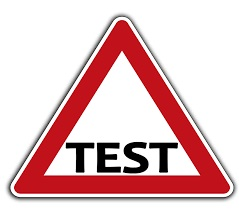

DEBUG - Deleted doc=5656473a-5ac4-4ab0-a1d8-a9115ac2ec47
DEBUG - Deleted transformer=53c935fa-abc6-4b76-8849-2c4082c59882
DEBUG - Deleted user=35b28576-1ec4-4800-b7b2-5b15a3eb0fb6
DEBUG - Deleted user=20f1a71c-f090-41fe-8b8d-3caeacfb2f39


In [65]:
def test_simple_media_transformer():
    user1=pac.userCreate(name="test_simple_user1",balance=1000)
    log.debug(f"Created user={user1}")
    
    transformer=pac.transformCreate("test_simple", {"chain":"_dbg_text2image"},owner=user1["uid"])
    log.debug(f"Created transformer={transformer} by user={user1['uid']}")

    user2=pac.userCreate(name="test_simple_user2",balance=1000)
    log.debug(f"Created user={user2}\n")

    log.debug(f"Requesting user={user2['uid']}")
    log.debug(f"Transformer owner={user1['uid']}")
    log.debug(f"Applying transformer={transformer['uid']}...")
    doc=pac.transformApply(transformer["uid"],user2["uid"], {"ssText":"sample text"})
    
    res=pac.pollForStatus(doc["did"],status="ready")
    log.debug(f"Polling result={res}\n")
    
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    
    log.debug(f"Requesting user {user2['uid']} expected balance: {1000}")
    log.debug(f"Transformer owner {user1['uid']} expected balance: {1000}")
    
    log.debug(f"Requesting user is {pac.userGet(user2['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user1['uid'])}\n")
    
    doc=pac.docFormat(doc["did"],fmt="json_base64")
    log.debug("Displaying media file embedded")
    display(Image.open(b642bin(doc['content']['bjImage'])))
    
    doc=pac.docDelete(doc["uid"])
    log.debug(f"Deleted doc={doc}")

    transformer=pac.transformDelete(transformer["uid"])
    log.debug(f"Deleted transformer={transformer}")

    user1=pac.userDelete(user1["uid"])
    log.debug(f"Deleted user={user1}")
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    
test_simple_media_transformer()

DEBUG - Created user={'name': 'test_simple_user1', 'balance': 1000, 'uid': '73fccb20-9dd6-4d08-8188-58fc0e2f945f', 'datecreated': '2023-07-08 13:26:53.655254'}
DEBUG - Created transformer={'name': 'test_simple', 'cfg': {'vars': {'size': '512x512'}, 'chain': '_openai_text2image'}, 'owner': '73fccb20-9dd6-4d08-8188-58fc0e2f945f', 'fees': {}, 'uid': '86e3d703-4b65-44e8-b5ca-aa9db39d6ce8', 'datecreated': '2023-07-08 13:26:54.275265'} by user=73fccb20-9dd6-4d08-8188-58fc0e2f945f
DEBUG - Created user={'name': 'test_simple_user2', 'balance': 1000, 'uid': '7114ecfa-66f3-4731-a6ae-fdb92ec51db0', 'datecreated': '2023-07-08 13:26:54.895236'}

DEBUG - Requesting user=7114ecfa-66f3-4731-a6ae-fdb92ec51db0
DEBUG - Transformer owner=73fccb20-9dd6-4d08-8188-58fc0e2f945f
DEBUG - Applying transformer=86e3d703-4b65-44e8-b5ca-aa9db39d6ce8...
DEBUG - Polling result=ready

DEBUG - Resulting document={'uid': '13413e8e-1703-4cd0-907a-907f3cbca2a1', 'status': 'ready', 'content': {'ssText': 'generate cute dog', 

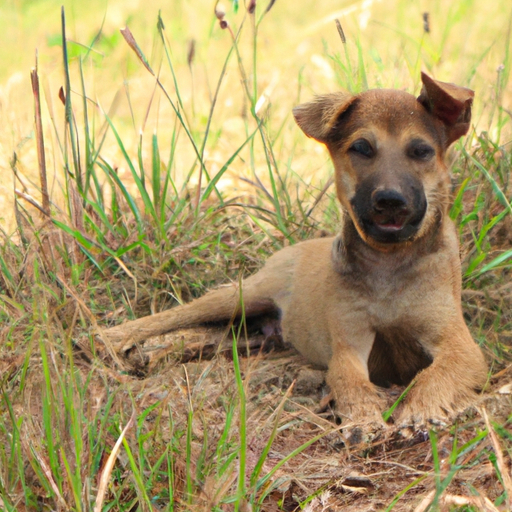

DEBUG - Deleted doc=13413e8e-1703-4cd0-907a-907f3cbca2a1
DEBUG - Deleted transformer=86e3d703-4b65-44e8-b5ca-aa9db39d6ce8
DEBUG - Deleted user=73fccb20-9dd6-4d08-8188-58fc0e2f945f
DEBUG - Deleted user=7114ecfa-66f3-4731-a6ae-fdb92ec51db0


In [68]:
def test_openai_media_transformer():
    user1=pac.userCreate(name="test_simple_user1",balance=1000)
    log.debug(f"Created user={user1}")
    
    transformer=pac.transformCreate("test_simple", {"vars": {"size":"512x512"},"chain":"_openai_text2image"},owner=user1["uid"])
    log.debug(f"Created transformer={transformer} by user={user1['uid']}")

    user2=pac.userCreate(name="test_simple_user2",balance=1000)
    log.debug(f"Created user={user2}\n")

    log.debug(f"Requesting user={user2['uid']}")
    log.debug(f"Transformer owner={user1['uid']}")
    log.debug(f"Applying transformer={transformer['uid']}...")
    doc=pac.transformApply(transformer["uid"],user2["uid"], {"ssText":"generate cute dog"})
    
    res=pac.pollForStatus(doc["did"],status="ready")
    log.debug(f"Polling result={res}\n")
    
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    
    log.debug(f"Requesting user {user2['uid']} expected balance: {1000}")
    log.debug(f"Transformer owner {user1['uid']} expected balance: {1000}")
    
    log.debug(f"Requesting user is {pac.userGet(user2['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user1['uid'])}\n")
    
    doc=pac.docFormat(doc["did"],fmt="json_base64")
    log.debug("Displaying media file embedded")
    display(Image.open(b642bin(doc['content']['bjImage'])))
    
    doc=pac.docDelete(doc["uid"])
    log.debug(f"Deleted doc={doc}")

    transformer=pac.transformDelete(transformer["uid"])
    log.debug(f"Deleted transformer={transformer}")

    user1=pac.userDelete(user1["uid"])
    log.debug(f"Deleted user={user1}")
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    
test_openai_media_transformer()

### compose transformer with mapping T(T(T(dbg_text2test), T(openai_text2text)), T(openai_text2text)) <a class="anchor" id="compose_transformer_with_mapping"></a>

In [69]:
def test_compose_transformer_map():

    user1=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user1}")
    transformer1=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2text"},owner=user1["uid"],fees={"prompt_fees":{user1["uid"]:15}})
    log.debug(f"Created transformer={transformer1} by user={user1['uid']}\n")

    user2=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user2}")
    transformer2=pac.transformCreate("test_complex_v1", {"chain":"_openai_text2text"},owner=user2["uid"],fees={"prompt_fees":{user2["uid"]:5}})
    log.debug(f"Created transformer={transformer2} by user={user2['uid']}\n")

    user3=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user3}")
    transformer3=pac.transformCreate("test_complex_v1", {"chain":[transformer1["uid"], transformer2["uid"]]}, mapio={'1':{"ssText":"based on {{chain[\"0\"][\"out_doc\"][\"ssText\"]}}"}}, owner=user3["uid"],fees={"prompt_fees":{user3["uid"]:2}})
    log.debug(f"Created transformer={transformer3} by user={user3['uid']}\n")


    user4=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user4}")
    transformer4=pac.transformCreate("test_complex_v1", {"chain":[transformer3["uid"], transformer2["uid"]]},mapio={'1':{"ssText":"translate to french: {{chain[\"0\"][\"out_doc\"][\"ssText\"]}}"}}, owner=user4["uid"],
                                     fees={"prompt_fees":{user4["uid"]:4}})
    log.debug(f"Created transformer={transformer4} by user={user4['uid']}\n")
    
    
    log.debug(f"Requesting user={user1['uid']}")
    log.debug(f"Transformer owner={user4['uid']}")
    log.debug(f"Nested Transformer owner={user2['uid']}")
    log.debug(f"Nested Transformer owner={user3['uid']}")
    log.debug(f"Applying transformer={transformer4['uid']}...")
    doc=pac.transformApply(transformer4["uid"],user1["uid"], {"ssText":"generate joke about ai"})
    res=pac.pollForStatus(doc["did"],max_duration_ms=80000, status="ready")
    log.debug(f"Polling result={res}\n")
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    log.debug(f"Requesting user {user1['uid']} expected balance: {1000-4-10-2}")
    log.debug(f"Transformer owner {user4['uid']} expected balance: {1000+4}")
    log.debug(f"Nested Transformer owner {user2['uid']} expected balance: {1000+5+5}")
    log.debug(f"Nested Transformer owner {user3['uid']} expected balance: {1000+2}")
    log.debug(f"Requesting user is {pac.userGet(user1['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user4['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user2['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user3['uid'])}\n")
    
    doc=pac.docDelete(doc["did"])
    log.debug(f"Deleted doc={doc}")
    
    transformer4=pac.transformDelete(transformer4["uid"])
    log.debug(f"Deleted transformer={transformer4}")
    transformer3=pac.transformDelete(transformer3["uid"])
    log.debug(f"Deleted transformer={transformer3}")
    transformer2=pac.transformDelete(transformer2["uid"])
    log.debug(f"Deleted transformer={transformer2}")
    transformer1=pac.transformDelete(transformer1["uid"])
    log.debug(f"Deleted transformer={transformer1}")

    user1=pac.userDelete(user1["uid"])
    log.debug(f"Deleted user={user1}")
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    user3=pac.userDelete(user3["uid"])
    log.debug(f"Deleted user={user3}")
    user4=pac.userDelete(user4["uid"])
    log.debug(f"Deleted user={user4}")
    
test_compose_transformer_map()

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': '2d883e58-0f66-4228-9db3-a167f67ababe', 'datecreated': '2023-07-08 13:27:21.156163'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_text2text'}, 'owner': '2d883e58-0f66-4228-9db3-a167f67ababe', 'fees': {'prompt_fees': {'2d883e58-0f66-4228-9db3-a167f67ababe': 15}}, 'uid': 'd8b20a5e-f0d0-470f-add1-3725de26a319', 'datecreated': '2023-07-08 13:27:21.776161'} by user=2d883e58-0f66-4228-9db3-a167f67ababe

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': '4c9bafba-373f-4b44-90f7-d8f2af468b6a', 'datecreated': '2023-07-08 13:27:22.416140'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_openai_text2text'}, 'owner': '4c9bafba-373f-4b44-90f7-d8f2af468b6a', 'fees': {'prompt_fees': {'4c9bafba-373f-4b44-90f7-d8f2af468b6a': 5}}, 'uid': 'e08f1dfe-d637-4ed0-90fd-debdd1ffac6e', 'datecreated': '2023-07-08 13:27:23.039024'} by user=4c9bafba-373f-4b44-9

### compose media transformer with mapping T(T(T(openai_text2text), T(openai_text2text)), T(openai_image2text)) <a class="anchor" id="compose_media_transformer_with_mapping"></a>

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': '76d55c04-66cf-4934-b8ff-5bdd880ba9ff', 'datecreated': '2023-07-08 13:27:58.317072'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_openai_text2text'}, 'owner': '76d55c04-66cf-4934-b8ff-5bdd880ba9ff', 'fees': {'prompt_fees': {'76d55c04-66cf-4934-b8ff-5bdd880ba9ff': 15}}, 'uid': '17a66fa8-580b-4e4d-8ac4-ed5d93d31c01', 'datecreated': '2023-07-08 13:27:58.937085'} by user=76d55c04-66cf-4934-b8ff-5bdd880ba9ff

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': 'b4d60492-958b-4e5d-b315-a5ca611a9013', 'datecreated': '2023-07-08 13:27:59.537048'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'vars': {'size': '512x512'}, 'chain': '_openai_text2image'}, 'owner': 'b4d60492-958b-4e5d-b315-a5ca611a9013', 'fees': {'prompt_fees': {'b4d60492-958b-4e5d-b315-a5ca611a9013': 5}}, 'uid': 'ff2ff685-a779-473e-a2ec-ea0e83394a58', 'datecreated': '2023-07-08 13:28:00.2570

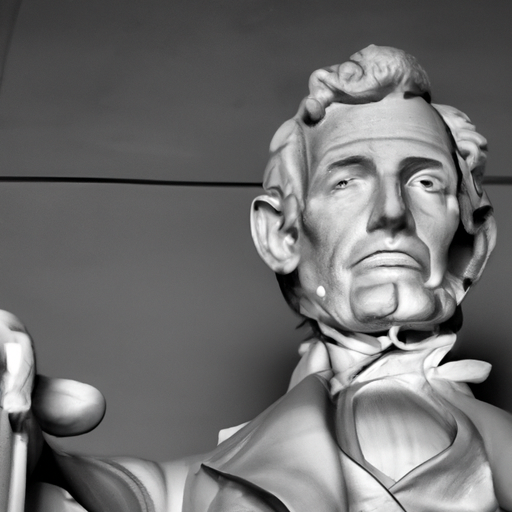

DEBUG - Deleted doc=705f1402-9048-46f5-9f72-a075f00e90b0
DEBUG - Deleted transformer=cbf830fb-a3fc-4882-a63d-b35997ed099c
DEBUG - Deleted transformer=7ba05759-d5e2-46b2-a30e-2a24f213822d
DEBUG - Deleted transformer=ff2ff685-a779-473e-a2ec-ea0e83394a58
DEBUG - Deleted transformer=17a66fa8-580b-4e4d-8ac4-ed5d93d31c01
DEBUG - Deleted user=76d55c04-66cf-4934-b8ff-5bdd880ba9ff
DEBUG - Deleted user=b4d60492-958b-4e5d-b315-a5ca611a9013
DEBUG - Deleted user=b92e5022-2f0a-4798-a9f3-5eae981aae41
DEBUG - Deleted user=14166490-b48f-4517-951b-55fcdb63c807


In [70]:
def test_compose_media_transformer_map():

    user1=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user1}")
    transformer1=pac.transformCreate("test_complex_v1", {"chain":"_openai_text2text"},owner=user1["uid"],fees={"prompt_fees":{user1["uid"]:15}})
    log.debug(f"Created transformer={transformer1} by user={user1['uid']}\n")

    user2=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user2}")
    transformer2=pac.transformCreate("test_complex_v1", {"vars": {"size":"512x512"},"chain":"_openai_text2image"},owner=user2["uid"],fees={"prompt_fees":{user2["uid"]:5}})
    log.debug(f"Created transformer={transformer2} by user={user2['uid']}\n")

    user3=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user3}")
    transformer3=pac.transformCreate("test_complex_v1", {"chain":[transformer1["uid"], transformer1["uid"]]}, mapio={'1':{"ssText":"I want you make Linkoln the main person in text: {{chain[\"0\"][\"out_doc\"][\"ssText\"]}}"}}, owner=user3["uid"],fees={"prompt_fees":{user3["uid"]:2}})
    log.debug(f"Created transformer={transformer3} by user={user3['uid']}\n")


    user4=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user4}")
    transformer4=pac.transformCreate("test_complex_v1", {"chain":[transformer3["uid"], transformer2["uid"]]},mapio={'1':{"ssText":"generate black-white image based on {{chain[\"0\"][\"out_doc\"][\"ssText\"]}}"}}, owner=user4["uid"],
                                     fees={"prompt_fees":{user4["uid"]:4}})
    log.debug(f"Created transformer={transformer4} by user={user4['uid']}\n")
    
    
    log.debug(f"Requesting user={user1['uid']}")
    log.debug(f"Transformer owner={user4['uid']}")
    log.debug(f"Nested Transformer owner={user2['uid']}")
    log.debug(f"Nested Transformer owner={user3['uid']}")
    log.debug(f"Applying transformer={transformer4['uid']}...")
    doc=pac.transformApply(transformer4["uid"],user1["uid"], {"ssText":"generate story about Berlin"})
    res=pac.pollForStatus(doc["did"],max_duration_ms=80000, poll_interval_ms=10000, status="ready")
    log.debug(f"Polling result={res}\n")
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    log.debug(f"Requesting user {user1['uid']} expected balance: {1000-5-4-2}")
    log.debug(f"Transformer owner {user4['uid']} expected balance: {1000+4}")
    log.debug(f"Nested Transformer owner {user2['uid']} expected balance: {1000+5}")
    log.debug(f"Nested Transformer owner {user3['uid']} expected balance: {1000+2}")
    log.debug(f"Requesting user is {pac.userGet(user1['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user4['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user2['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user3['uid'])}\n")
    
    log.debug(f"Image created based on this prompt: {pac.docFormat(doc['did'])['content']['ssText']}")
    
    doc=pac.docFormat(doc["did"],fmt="json_base64")
    log.debug("Displaying media file embedded")
    display(Image.open(b642bin(doc['content']['bjImage'])))
    
    doc=pac.docDelete(doc["uid"])
    log.debug(f"Deleted doc={doc}")
    
    transformer4=pac.transformDelete(transformer4["uid"])
    log.debug(f"Deleted transformer={transformer4}")
    transformer3=pac.transformDelete(transformer3["uid"])
    log.debug(f"Deleted transformer={transformer3}")
    transformer2=pac.transformDelete(transformer2["uid"])
    log.debug(f"Deleted transformer={transformer2}")
    transformer1=pac.transformDelete(transformer1["uid"])
    log.debug(f"Deleted transformer={transformer1}")

    user1=pac.userDelete(user1["uid"])
    log.debug(f"Deleted user={user1}")
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    user3=pac.userDelete(user3["uid"])
    log.debug(f"Deleted user={user3}")
    user4=pac.userDelete(user4["uid"])
    log.debug(f"Deleted user={user4}")
    
test_compose_media_transformer_map()

### compose transformer T(T(dbg_text2test), T(dbg_text2text)) <a class="anchor" id="compose_transformer1"></a>

In [71]:
def test_compose_transformer1():
    user1=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user1}")
    
    transformer1=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2text"},owner=user1["uid"],fees={"prompt_fees":{user1["uid"]:15}})
    log.debug(f"Created transformer={transformer1} by user={user1['uid']}")
    transformer2=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2text"},owner=user1["uid"],fees={"prompt_fees":{user1["uid"]:5}})
    log.debug(f"Created transformer={transformer2} by user={user1['uid']}\n")

    user2=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user2}")
    transformer3=pac.transformCreate("test_complex_v1", {"chain":[transformer1["uid"], transformer2["uid"]]},owner=user2["uid"],
                                     fees={"prompt_fees":{user2["uid"]:5}})
    log.debug(f"Created transformer={transformer3} by user={user2['uid']}\n")

    user3=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user3}")
    
    
    log.debug(f"Requesting user={user3['uid']}")
    log.debug(f"Transformer owner={user2['uid']}")
    log.debug(f"Nested Transformer owner={user1['uid']}")
    log.debug(f"Applying transformer={transformer3['uid']}...")
    doc=pac.transformApply(transformer3["uid"],user3["uid"], {"ssText":"sample text"})
    
    res=pac.pollForStatus(doc["did"],status="ready")
    log.debug(f"Polling result={res}\n")
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    log.debug(f"Requesting user {user3['uid']} expected balance: {975}")
    log.debug(f"Transformer owner {user2['uid']} expected balance: {1005}")
    log.debug(f"Nested Transformer owner {user1['uid']} expected balance: {1020}")
    log.debug(f"Requesting user is {pac.userGet(user3['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user2['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user1['uid'])}\n")

    transformer3=pac.transformDelete(transformer3["uid"])
    log.debug(f"Deleted transformer={transformer3}")
    transformer2=pac.transformDelete(transformer2["uid"])
    log.debug(f"Deleted transformer={transformer2}")
    transformer1=pac.transformDelete(transformer1["uid"])
    log.debug(f"Deleted transformer={transformer1}")
    
    doc=pac.docDelete(doc["did"])
    log.debug(f"Deleted doc={doc}")
    
    user1=pac.userDelete(user1["uid"])
    log.debug(f"Deleted user={user1}")
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    user3=pac.userDelete(user3["uid"])
    log.debug(f"Deleted user={user3}")
    
test_compose_transformer1()

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': 'e42353bb-7fb4-411b-8bed-c26a238246c5', 'datecreated': '2023-07-08 13:29:02.661136'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_text2text'}, 'owner': 'e42353bb-7fb4-411b-8bed-c26a238246c5', 'fees': {'prompt_fees': {'e42353bb-7fb4-411b-8bed-c26a238246c5': 15}}, 'uid': 'a23dc67b-699b-4048-b355-b9431a955065', 'datecreated': '2023-07-08 13:29:03.257958'} by user=e42353bb-7fb4-411b-8bed-c26a238246c5
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_text2text'}, 'owner': 'e42353bb-7fb4-411b-8bed-c26a238246c5', 'fees': {'prompt_fees': {'e42353bb-7fb4-411b-8bed-c26a238246c5': 5}}, 'uid': 'b12deebb-3345-44f8-aa81-8a340064e8e0', 'datecreated': '2023-07-08 13:29:03.897961'} by user=e42353bb-7fb4-411b-8bed-c26a238246c5

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': '547808ba-9cdb-40ba-a9df-802f3b25fc69', 'datecreated': '2023-07-08 13:2

### compose transformer T(T(dbg_text2image), T(dbg_img2text)) <a class="anchor" id="compose_transformer2"></a>

In [72]:
def test_compose_transformer2():

    user1=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user1}")
    transformer1=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2image"},owner=user1["uid"],fees={"prompt_fees":{user1["uid"]:15}})
    log.debug(f"Created transformer={transformer1} by user={user1['uid']}")
    transformer2=pac.transformCreate("test_complex_v1", {"chain":"_dbg_img2text"},owner=user1["uid"],fees={"prompt_fees":{user1["uid"]:5}})
    log.debug(f"Created transformer={transformer2} by user={user1['uid']}\n")

    user2=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user2}")
    transformer3=pac.transformCreate("test_complex_v1", {"chain":[transformer1["uid"], transformer2["uid"]]},owner=user2["uid"],
                                     fees={"prompt_fees":{user2["uid"]:5}})
    log.debug(f"Created transformer={transformer3} by user={user2['uid']}\n")

    user3=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user3}")
    
    log.debug(f"Requesting user={user3['uid']}")
    log.debug(f"Transformer owner={user2['uid']}")
    log.debug(f"Nested Transformer owner={user1['uid']}")
    log.debug(f"Applying transformer={transformer3['uid']}...")
    doc=pac.transformApply(transformer3["uid"],user3["uid"], {"ssText":"sample text"})
    
    res=pac.pollForStatus(doc["did"],status="ready")
    log.debug(f"Polling result={res}\n")
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    log.debug(f"Requesting user {user3['uid']} expected balance: {975}")
    log.debug(f"Transformer owner {user2['uid']} expected balance: {1005}")
    log.debug(f"Nested Transformer owner {user1['uid']} expected balance: {1020}")
    log.debug(f"Requesting user is {pac.userGet(user3['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user2['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user1['uid'])}\n")

    doc=pac.docDelete(doc["did"])
    log.debug(f"Deleted doc={doc}")
    
    transformer3=pac.transformDelete(transformer3["uid"])
    log.debug(f"Deleted transformer={transformer3}")
    transformer2=pac.transformDelete(transformer2["uid"])
    log.debug(f"Deleted transformer={transformer2}")
    transformer1=pac.transformDelete(transformer1["uid"])
    log.debug(f"Deleted transformer={transformer1}")

    user1=pac.userDelete(user1["uid"])
    log.debug(f"Deleted user={user1}")
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    user3=pac.userDelete(user3["uid"])
    log.debug(f"Deleted user={user3}")

test_compose_transformer2()

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': '8f3d62f2-d516-471e-a486-b21211cf50ff', 'datecreated': '2023-07-08 13:29:20.601134'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_text2image'}, 'owner': '8f3d62f2-d516-471e-a486-b21211cf50ff', 'fees': {'prompt_fees': {'8f3d62f2-d516-471e-a486-b21211cf50ff': 15}}, 'uid': '03f4d627-0824-4242-93e6-c10cf64144ea', 'datecreated': '2023-07-08 13:29:21.221134'} by user=8f3d62f2-d516-471e-a486-b21211cf50ff
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_img2text'}, 'owner': '8f3d62f2-d516-471e-a486-b21211cf50ff', 'fees': {'prompt_fees': {'8f3d62f2-d516-471e-a486-b21211cf50ff': 5}}, 'uid': 'b0bd2a71-4f5b-4a6c-8e66-422a6deba9ba', 'datecreated': '2023-07-08 13:29:21.861149'} by user=8f3d62f2-d516-471e-a486-b21211cf50ff

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': '3c2d9104-218a-4e20-98ab-6c5f6fece93d', 'datecreated': '2023-07-08 13:2

### compose transformer T(T(T(T(dbg_text2image),T(dbg_image2text)), T(dbg_text2text)), T(dbg_text2image)) <a class="anchor" id="compose_transformer3"></a>

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': '24438080-d6d2-4acc-82cc-d40f343e0eb5', 'datecreated': '2023-07-08 13:29:41.377974'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_text2image'}, 'owner': '24438080-d6d2-4acc-82cc-d40f343e0eb5', 'fees': {'prompt_fees': {'24438080-d6d2-4acc-82cc-d40f343e0eb5': 15}}, 'uid': '21708794-f09c-46a9-afc8-62a7b53c2105', 'datecreated': '2023-07-08 13:29:41.997955'} by user=24438080-d6d2-4acc-82cc-d40f343e0eb5

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': 'd53a53d0-398a-4d87-afe4-31e1a64e5aab', 'datecreated': '2023-07-08 13:29:42.638012'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_img2text'}, 'owner': 'd53a53d0-398a-4d87-afe4-31e1a64e5aab', 'fees': {'prompt_fees': {'d53a53d0-398a-4d87-afe4-31e1a64e5aab': 5}}, 'uid': '401a31f4-e55f-4b98-ac76-46f8caffa064', 'datecreated': '2023-07-08 13:29:43.261246'} by user=d53a53d0-398a-4d87-afe4

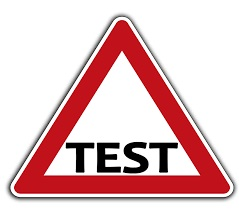

DEBUG - Deleted doc=40fd4801-6a5e-46b3-a600-857fec35a31c
DEBUG - Deleted transformer=19fb6440-69b2-4362-bbf1-7fa49beb8dce
DEBUG - Deleted transformer=37255ba9-54c2-4337-a462-5691a3522b38
DEBUG - Deleted transformer=b3e065a1-eacb-4469-afbb-f361b80853b4
DEBUG - Deleted transformer=f6dbf8ce-cca0-44cb-8fef-dbd507fe7f87
DEBUG - Deleted transformer=401a31f4-e55f-4b98-ac76-46f8caffa064
DEBUG - Deleted transformer=21708794-f09c-46a9-afc8-62a7b53c2105
DEBUG - Deleted user=24438080-d6d2-4acc-82cc-d40f343e0eb5
DEBUG - Deleted user=d53a53d0-398a-4d87-afe4-31e1a64e5aab
DEBUG - Deleted user=aee32648-4012-40ce-adb8-4311f1f762b0
DEBUG - Deleted user=9d9aa801-6c7c-4fcc-85b0-a31fa8f28545
DEBUG - Deleted user=e9eea428-0d2b-44eb-b967-d1c06a1eed30
DEBUG - Deleted user=aa4a48c5-a5d7-41fe-a982-a2054f6c5a8d


In [73]:
def test_compose_transformer3():

    user1=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user1}")
    transformer1=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2image"},owner=user1["uid"],fees={"prompt_fees":{user1["uid"]:15}})
    log.debug(f"Created transformer={transformer1} by user={user1['uid']}\n")

    user2=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user2}")
    transformer2=pac.transformCreate("test_complex_v1", {"chain":"_dbg_img2text"},owner=user2["uid"],fees={"prompt_fees":{user2["uid"]:5}})
    log.debug(f"Created transformer={transformer2} by user={user2['uid']}\n")

    user3=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user3}")
    transformer3=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2text"},owner=user3["uid"],fees={"prompt_fees":{user3["uid"]:2}})
    log.debug(f"Created transformer={transformer3} by user={user3['uid']}\n")


    user4=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user4}")
    transformer4=pac.transformCreate("test_complex_v1", {"chain":[transformer1["uid"], transformer2["uid"]]},owner=user4["uid"],
                                     fees={"prompt_fees":{user4["uid"]:4}})
    log.debug(f"Created transformer={transformer4} by user={user4['uid']}\n")


    user5=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user5}")
    transformer5=pac.transformCreate("test_complex_v1", {"chain":[transformer4["uid"], transformer3["uid"]]},owner=user5["uid"],
                                     fees={"prompt_fees":{user5["uid"]:1}})
    log.debug(f"Created transformer={transformer5} by user={user5['uid']}\n")


    transformer6=pac.transformCreate("test_complex_v1", {"chain":[transformer5["uid"], transformer1["uid"]]},owner=user2["uid"],
                                     fees={"prompt_fees":{user2["uid"]:30}})
    log.debug(f"Created transformer={transformer6} by user={user2['uid']}\n")


    user6=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user6}")
    
    
    log.debug(f"Requesting user={user6['uid']}")
    log.debug(f"Transformer owner={user2['uid']}")
    log.debug(f"Nested Transformer owner={user1['uid']}")
    log.debug(f"Nested Transformer owner={user5['uid']}")
    log.debug(f"Nested Transformer owner={user3['uid']}")
    log.debug(f"Nested Transformer owner={user4['uid']}")
    log.debug(f"Applying transformer={transformer6['uid']}...")
    doc=pac.transformApply(transformer6["uid"],user6["uid"], {"ssText":"sample text"})
    res=pac.pollForStatus(doc["did"],status="ready")
    log.debug(f"Polling result={res}\n")
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    log.debug(f"Requesting user {user6['uid']} expected balance: {1000-30-1-4-2-5-15-15}")
    log.debug(f"Transformer owner {user2['uid']} expected balance: {1000+30+5}")
    log.debug(f"Nested Transformer owner {user1['uid']} expected balance: {1000+15+15}")
    log.debug(f"Nested Transformer owner {user5['uid']} expected balance: {1000+1}")
    log.debug(f"Nested Transformer owner {user3['uid']} expected balance: {1000+2}")
    log.debug(f"Nested Transformer owner {user4['uid']} expected balance: {1000+4}")
    log.debug(f"Requesting user is {pac.userGet(user6['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user2['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user1['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user5['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user3['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user4['uid'])}\n")


    doc=pac.docFormat(doc["did"],fmt="json_base64")
    log.debug("Displaying media file embedded")
    display(Image.open(b642bin(doc['content']['bjImage'])))
    
    doc=pac.docDelete(doc["uid"])
    log.debug(f"Deleted doc={doc}")
    
    transformer6=pac.transformDelete(transformer6["uid"])
    log.debug(f"Deleted transformer={transformer6}")
    transformer5=pac.transformDelete(transformer5["uid"])
    log.debug(f"Deleted transformer={transformer5}")
    transformer4=pac.transformDelete(transformer4["uid"])
    log.debug(f"Deleted transformer={transformer4}")
    transformer3=pac.transformDelete(transformer3["uid"])
    log.debug(f"Deleted transformer={transformer3}")
    transformer2=pac.transformDelete(transformer2["uid"])
    log.debug(f"Deleted transformer={transformer2}")
    transformer1=pac.transformDelete(transformer1["uid"])
    log.debug(f"Deleted transformer={transformer1}")

    user1=pac.userDelete(user1["uid"])
    log.debug(f"Deleted user={user1}")
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    user3=pac.userDelete(user3["uid"])
    log.debug(f"Deleted user={user3}")
    user4=pac.userDelete(user4["uid"])
    log.debug(f"Deleted user={user4}")
    user5=pac.userDelete(user5["uid"])
    log.debug(f"Deleted user={user5}")
    user6=pac.userDelete(user6["uid"])
    log.debug(f"Deleted user={user6}")
    
test_compose_transformer3()

### compose transformer T(T(T(T(dbg_src), T(dbg_text2text)), T(dbg_text2image), T(dbg_image2text)), T(dbg_text2image)) <a class="anchor" id="compose_transformer4"></a>

In [74]:
def test_compose_transformer4():

    user1=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user1}")
    transformer1=pac.transformCreate("test_complex_v1", {"chain":"_dbg_src"},owner=user1["uid"],fees={"prompt_fees":{user1["uid"]:15}})
    log.debug(f"Created transformer={transformer1} by user={user1['uid']}\n")

    user2=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user2}")
    transformer2=pac.transformCreate("test_complex_v1", {"chain":"_dbg_img2text"},owner=user2["uid"],fees={"prompt_fees":{user2["uid"]:5}})
    log.debug(f"Created transformer={transformer2} by user={user2['uid']}\n")

    user3=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user3}")
    transformer3=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2text"},owner=user3["uid"],fees={"prompt_fees":{user3["uid"]:2}})
    log.debug(f"Created transformer={transformer3} by user={user3['uid']}\n")

    user4=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user4}")
    transformer4=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2image"},owner=user4["uid"],fees={"prompt_fees":{user4["uid"]:2}})
    log.debug(f"Created transformer={transformer4} by user={user4['uid']}\n")

    user5=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user5}")
    transformer5=pac.transformCreate("test_complex_v1", {"chain":"_dbg_text2image"},owner=user5["uid"],fees={"prompt_fees":{user5["uid"]:1}})
    log.debug(f"Created transformer={transformer5} by user={user5['uid']}\n")


    user6=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user6}")
    transformer6=pac.transformCreate("test_complex_v1", {"chain":[transformer1["uid"], transformer3["uid"]]},owner=user6["uid"],
                                     fees={"prompt_fees":{user6["uid"]:4}})
    log.debug(f"Created transformer={transformer6} by user={user6['uid']}\n")


    user7=pac.userCreate(name="test_complex_v1",balance=1000)
    log.debug(f"Created user={user7}")
    transformer7=pac.transformCreate("test_complex_v1", {"chain":[transformer6["uid"], transformer4["uid"], transformer2["uid"]]},owner=user7["uid"],
                                     fees={"prompt_fees":{user7["uid"]:1}})
    log.debug(f"Created transformer={transformer7} by user={user7['uid']}\n")


    transformer8=pac.transformCreate("test_complex_v1", {"chain":[transformer7["uid"], transformer5["uid"]]},owner=user3["uid"],
                                     fees={"prompt_fees":{user3["uid"]:30}})
    log.debug(f"Created transformer={transformer8} by user={user3['uid']}\n")
    
    
    log.debug(f"Requesting user={user1['uid']}")
    log.debug(f"Transformer owner={user3['uid']}")
    log.debug(f"Nested Transformer owner={user7['uid']}")
    log.debug(f"Nested Transformer owner={user2['uid']}")
    log.debug(f"Nested Transformer owner={user6['uid']}")
    log.debug(f"Nested Transformer owner={user4['uid']}")
    log.debug(f"Nested Transformer owner={user5['uid']}")
    log.debug(f"Applying transformer={transformer8['uid']}...")
    doc=pac.transformApply(transformer8["uid"],user1["uid"], {"ssText":"my text"})
    res=pac.pollForStatus(doc["did"],status="ready")
    log.debug(f"Polling result={res}\n")
    log.debug(f"Resulting document={pac.docFormat(doc['did'])}")
    log.debug(f"Requesting user {user1['uid']} expected balance: {1000-30-1-4-2-2-5-1}")
    log.debug(f"Transformer owner {user3['uid']} expected balance: {1000+30+2}")
    log.debug(f"Nested Transformer owner {user7['uid']} expected balance: {1000+1}")
    log.debug(f"Nested Transformer owner {user2['uid']} expected balance: {1000+5}")
    log.debug(f"Nested Transformer owner {user6['uid']} expected balance: {1000+4}")
    log.debug(f"Nested Transformer owner {user4['uid']} expected balance: {1000+2}")
    log.debug(f"Nested Transformer owner {user5['uid']} expected balance: {1000+1}")
    log.debug(f"Requesting user is {pac.userGet(user1['uid'])}")
    log.debug(f"Transformer owner is {pac.userGet(user3['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user7['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user2['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user6['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user4['uid'])}")
    log.debug(f"Nested Transformer owner is {pac.userGet(user5['uid'])}\n")
    
    doc=pac.docDelete(doc["did"])
    log.debug(f"Deleted doc={doc}")
    
    transformer8=pac.transformDelete(transformer8["uid"])
    log.debug(f"Deleted transformer={transformer8}")
    transformer7=pac.transformDelete(transformer7["uid"])
    log.debug(f"Deleted transformer={transformer7}")
    transformer6=pac.transformDelete(transformer6["uid"])
    log.debug(f"Deleted transformer={transformer6}")
    transformer5=pac.transformDelete(transformer5["uid"])
    log.debug(f"Deleted transformer={transformer5}")
    transformer4=pac.transformDelete(transformer4["uid"])
    log.debug(f"Deleted transformer={transformer4}")
    transformer3=pac.transformDelete(transformer3["uid"])
    log.debug(f"Deleted transformer={transformer3}")
    transformer2=pac.transformDelete(transformer2["uid"])
    log.debug(f"Deleted transformer={transformer2}")
    transformer1=pac.transformDelete(transformer1["uid"])
    log.debug(f"Deleted transformer={transformer1}")
    
    
    user1=pac.userDelete(user1["uid"])
    log.debug(f"Deleted user={user1}")
    user2=pac.userDelete(user2["uid"])
    log.debug(f"Deleted user={user2}")
    user3=pac.userDelete(user3["uid"])
    log.debug(f"Deleted user={user3}")
    user4=pac.userDelete(user4["uid"])
    log.debug(f"Deleted user={user4}")
    user5=pac.userDelete(user5["uid"])
    log.debug(f"Deleted user={user5}")
    user6=pac.userDelete(user6["uid"])
    log.debug(f"Deleted user={user6}")
    user7=pac.userDelete(user7["uid"])
    log.debug(f"Deleted user={user7}")

test_compose_transformer4()

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': 'f9446397-4cee-428b-85be-aadc66f61d4e', 'datecreated': '2023-07-08 13:30:14.498917'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_src'}, 'owner': 'f9446397-4cee-428b-85be-aadc66f61d4e', 'fees': {'prompt_fees': {'f9446397-4cee-428b-85be-aadc66f61d4e': 15}}, 'uid': '5da96008-30c7-4098-9427-35457d389c3c', 'datecreated': '2023-07-08 13:30:15.098851'} by user=f9446397-4cee-428b-85be-aadc66f61d4e

DEBUG - Created user={'name': 'test_complex_v1', 'balance': 1000, 'uid': '2c81e333-c12a-42a7-8a9e-e8be96bdd7db', 'datecreated': '2023-07-08 13:30:15.758877'}
DEBUG - Created transformer={'name': 'test_complex_v1', 'cfg': {'chain': '_dbg_img2text'}, 'owner': '2c81e333-c12a-42a7-8a9e-e8be96bdd7db', 'fees': {'prompt_fees': {'2c81e333-c12a-42a7-8a9e-e8be96bdd7db': 5}}, 'uid': 'bd08061e-4d5a-4627-b100-4ae4cd0a1093', 'datecreated': '2023-07-08 13:30:16.381599'} by user=2c81e333-c12a-42a7-8a9e-e8be96

DEBUG - Nested Transformer owner is {'uid': '3304ef0d-b78b-4a14-80fb-f53ba133f9d5', 'name': 'test_complex_v1', 'balance': 1001.0, 'datecreated': '2023-07-08 13:30:19.501602', 'email': None, 'subscription': None}

DEBUG - Deleted doc=ea5a8b75-2227-4c92-90e3-bf234827fb14
DEBUG - Deleted transformer=31fcea84-f9c3-4045-b1f6-e45930120f0a
DEBUG - Deleted transformer=817f73d2-fd54-4c0a-a79e-6b4d77601fd9
DEBUG - Deleted transformer=9cb8937b-427a-40f7-b57c-19aa2ef710a3
DEBUG - Deleted transformer=48685bc3-590c-4dcd-9bef-ecc63bbef9d9
DEBUG - Deleted transformer=fbced6db-0ac8-46f4-8ff0-4a738e27395c
DEBUG - Deleted transformer=1f2794aa-32e6-4d90-af77-e66f5f61e58d
DEBUG - Deleted transformer=bd08061e-4d5a-4627-b100-4ae4cd0a1093
DEBUG - Deleted transformer=5da96008-30c7-4098-9427-35457d389c3c
DEBUG - Deleted user=f9446397-4cee-428b-85be-aadc66f61d4e
DEBUG - Deleted user=2c81e333-c12a-42a7-8a9e-e8be96bdd7db
DEBUG - Deleted user=205a65c7-0de6-4178-8228-1f9d80261136
DEBUG - Deleted user=ab0f45a1-be03-4

### node

In [493]:
def test_generate_feed():
    user1_create_response = pac.userCreate("Test User", 100)
    log.debug(f"Created user={user1_create_response}")
    trans_create_response = pac.transformCreate("Test Transformer", {"chain":"_dbg_text2text", "in_doc":{"ssText": "test text"}}, fees={"prompt_fees":{user1_create_response['uid']:20}},owner=user1_create_response['uid'])
    log.debug(f"Created transformer={trans_create_response} by user={user1_create_response['uid']}\n")
    user2_create_response = pac.userCreate("Test User", 100)
    log.debug(f"Created user={user2_create_response}")
    feed_create_response=pac.feedAttach(name="Test Feed", description="Test Feed", owner=user2_create_response['uid'], transformer=trans_create_response['uid'])
    log.debug(f"Created feed={feed_create_response} by user={user2_create_response['uid']}\n")
    user3_create_response = pac.userCreate("Test User", 100)
    log.debug(f"Created user={user3_create_response}")
    
    feed_generate_response=pac.feedGenerate(feed_create_response['uid'],uid=user3_create_response['uid'],maxnum=2)
    pac.feedPollForStatus(feed_generate_response["taskid"],max_duration_ms=10000,poll_interval_ms=500, status="ready")

    feed_user_docs_response = pac.feedDocs(feed_create_response['uid'],user3_create_response['uid'])
    doc_format_response = pac.docFormat(feed_user_docs_response[0]['uid'])
    log.debug(f"Generated {len(feed_user_docs_response)} doc owner={user3_create_response['uid']}")
    log.debug(f"Doc example: {doc_format_response}")
test_generate_feed()

DEBUG - Created user={'name': 'Test User', 'balance': 100, 'uid': 'd01a495d-31c2-4d1f-85bd-6875ff5134e2', 'datecreated': '2023-07-31 06:18:17.244854'}
DEBUG - Created transformer={'name': 'Test Transformer', 'cfg': {'chain': '_dbg_text2text', 'in_doc': {'ssText': 'test text'}}, 'owner': 'd01a495d-31c2-4d1f-85bd-6875ff5134e2', 'fees': {'prompt_fees': {'d01a495d-31c2-4d1f-85bd-6875ff5134e2': 20}}, 'uid': '4d46438a-1c61-4619-8c34-0a73f47a0822', 'datecreated': '2023-07-31 06:18:17.902029'} by user=d01a495d-31c2-4d1f-85bd-6875ff5134e2

DEBUG - Created user={'name': 'Test User', 'balance': 100, 'uid': 'd97da750-b499-4a43-b62e-ac3fa8445e44', 'datecreated': '2023-07-31 06:18:18.541943'}
DEBUG - Created feed={'fees': {'prompt_fees': {'d01a495d-31c2-4d1f-85bd-6875ff5134e2': 20}}, 'name': 'Test Feed', 'description': 'Test Feed', 'owner': 'd97da750-b499-4a43-b62e-ac3fa8445e44', 'transformer': '4d46438a-1c61-4619-8c34-0a73f47a0822', 'lastattempt': '0001-01-01 00:00:00', 'lastgen': '0001-01-01 00:00

### node from src <a class="anchor" id="node_from_src"></a>

In [180]:
# def test_generate_feed_having_parent():
#     user1_create_response = pac.userCreate("Test User", 100)
#     log.debug(f"Created user={user1_create_response}")
#     trans_create_response = pac.transformCreate("Test Transformer", {"chain":"_dbg_text2text", "in_doc":{"ssText": "test text"}}, fees={"prompt_fees":{user1_create_response['uid']:20}},owner=user1_create_response['uid'])
#     log.debug(f"Created transformer={trans_create_response} by user={user1_create_response['uid']}\n")
#     user2_create_response = pac.userCreate("Test User", 100)
#     log.debug(f"Created user={user2_create_response}")
#     feed_create_response=pac.feedAttach(name="Test Feed", description="Test Feed", owner=user2_create_response['uid'], transformer=trans_create_response['uid'])
#     log.debug(f"Created feed={feed_create_response} by user={user2_create_response['uid']}\n")
#     user3_create_response = pac.userCreate("Test User", 100)
#     log.debug(f"Created user={user3_create_response}")
    
#     feed_generate_response=pac.feedGenerate(feed_create_response['uid'],uid=user3_create_response['uid'],maxnum=2)
#     pac.feedPollForStatus(feed_generate_response["taskid"],max_duration_ms=10000,poll_interval_ms=500, status="ready")        
#     feed_user3_docs_response = pac.feedDocs(feed_create_response['uid'],user3_create_response['uid'])
#     log.debug(f"Generated {feed_user3_docs_response} doca owner={user3_create_response['uid']}")
    
#     user4_create_response = pac.userCreate("Test User", 100)
#     log.debug(f"Created user={user4_create_response}")
#     trans2_create_response = pac.transformCreate("Test Transformer", {"chain":"_dbg_text2text"}, fees={"prompt_fees":{user4_create_response['uid']:5}},owner=user4_create_response['uid'])
#     log.debug(f"Created transformer={trans2_create_response} by user={user4_create_response['uid']}\n")
#     user5_create_response = pac.userCreate("Test User", 100)
#     log.debug(f"Created user={user5_create_response}")
#     feed2_create_response=pac.feedAttach(name="Test Feed", description="Test Feed", owner=user5_create_response['uid'], transformer=trans2_create_response['uid'], source=feed_create_response['uid'])
#     log.debug(f"Created feed={feed2_create_response} by user={user5_create_response['uid']}, source={feed_create_response['uid']}\n")
    
#     user6_create_response = pac.userCreate("Test User", 100)
#     log.debug(f"Created user={user6_create_response}")
#     feed_generate2_response=pac.feedGenerate(feed2_create_response['uid'],uid=user6_create_response['uid'],maxnum=1)
#     pac.feedPollForStatus(feed_generate2_response["taskid"],max_duration_ms=10000,poll_interval_ms=500, status="ready")
#     feed_user6_docs_response = pac.feedDocs(feed2_create_response['uid'],user6_create_response['uid'])
#     log.debug(f"Generated {len(feed_user6_docs_response)} doc owner={user6_create_response['uid']}")
#     log.debug(f"Doc example: {pac.docFormat(feed_user6_docs_response[0]['uid'])}")
    
# test_generate_feed_having_parent()

In [ ]:
def test_node_with_parent():
    user1_create_response = pac.userCreate("Test User", 100)
    trans_create_response = pac.transformCreate("Test Transformer", {"chain":"_dbg_text2text", "in_doc":{"ssText": "test text"}}, fees={"prompt_fees":{user1_create_response['uid']:20}},owner=user1_create_response['uid'])
    user2_create_response = pac.userCreate("Test User", 100)
    feed_create_response=pac.feedAttach(name="Test Feed", description="Test Feed", owner=user2_create_response['uid'], transformer=trans_create_response['uid'])
    
    user3_create_response = pac.userCreate("Test User", 100)
    feed_generate_response=pac.feedGenerate(feed_create_response['uid'],uid=user3_create_response['uid'],maxnum=2)
    pac.feedPollForStatus(feed_generate_response["taskid"],max_duration_ms=10000,poll_interval_ms=500, status="ready")
    print(pac.feedDocs(feed_create_response['uid'],user3_create_response['uid']))
    print(feed_create_response)
    
    user4_create_response = pac.userCreate("Test User", 100)
    trans2_create_response = pac.transformCreate("Test Transformer", {"chain":"_dbg_text2text"}, fees={"prompt_fees":{user4_create_response['uid']:5}},owner=user4_create_response['uid'])
    user5_create_response = pac.userCreate("Test User", 100)
    feed2_create_response=pac.feedAttach(name="Test Feed", description="Test Feed", owner=user5_create_response['uid'], transformer=trans2_create_response['uid'], source=feed_create_response['uid'])
    print(feed2_create_response)
    
    user6_create_response = pac.userCreate("Test User", 100)
    feed_generate2_response=pac.feedGenerate(feed2_create_response['uid'],uid=user6_create_response['uid'],maxnum=1)
    pac.feedPollForStatus(feed_generate2_response["taskid"],max_duration_ms=10000,poll_interval_ms=500, status="ready")
    print(pac.feedDocs(feed2_create_response['uid'],user6_create_response['uid']))
    print(pac.userGet(user6_create_response['uid']))
    
    user7_create_response = pac.userCreate("Test User", 100)
    feed_generate2_response=pac.feedGenerate(feed2_create_response['uid'],uid=user7_create_response['uid'],maxnum=3)
    print(pac.feedDocs(feed2_create_response['uid'],user7_create_response['uid']))
    print(pac.userGet(user7_create_response['uid']))

In [202]:
import json
def test_splitter():
    user1_create_response = pac.userCreate("Test User", 100)
    trans_create_response = pac.transformCreate("Test Transformer", {"chain":"_dbg_text2text", "in_doc":{"ssText": "test text"}}, fees={"prompt_fees":{user1_create_response['uid']:20}},owner=user1_create_response['uid'])
    feed_create_response=pac.feedAttach(name="Test Feed", description="Test Feed", owner=user1_create_response['uid'], transformer=trans_create_response['uid'])

    feed_generate_response=pac.feedGenerate(feed_create_response['uid'],uid=user1_create_response['uid'],maxnum=1)
    pac.feedPollForStatus(feed_generate_response["taskid"],max_duration_ms=10000,poll_interval_ms=500, status="ready")

    docs=pac.feedDocs(feed_create_response['uid'],user1_create_response['uid'])
    print(docs)
    pac.docUpdate(docs[0]['uid'],content=json.dumps([{"ssText":"test text[]"}, {"ssText":"test text2[]"}]))
    
    user2_create_response = pac.userCreate("Test User", 100)
    feed2_create_response=pac.feedAttach(name="Test Feed", description="Test Feed", transformer=None, owner=user2_create_response['uid'], nodetype='splitter', source=feed_create_response['uid'])
    
    feed_generate2_response=pac.feedGenerate(feed2_create_response['uid'],uid=user2_create_response['uid'],maxnum=1)
    pac.feedPollForStatus(feed_generate2_response["taskid"],max_duration_ms=10000,poll_interval_ms=500, status="ready")

    print(pac.userGet(user2_create_response['uid']))
    print(pac.feedDocs(feed2_create_response['uid'],user2_create_response['uid']))
    print(pac.docFormat(pac.feedDocs(feed2_create_response['uid'],user2_create_response['uid'])[0]['uid'])['content'])
    print(pac.docFormat(pac.feedDocs(feed2_create_response['uid'],user2_create_response['uid'])[1]['uid'])['content'])

test_splitter()

[{'uid': '36fffbf9-c111-47f2-8868-89d706b11fee'}]
{'uid': '0b9356d9-8ba6-40bf-8f9b-5480ff0f39bf', 'name': 'Test User', 'balance': 80.0, 'datecreated': '2023-08-01 19:24:44.265091', 'email': None, 'subscription': None}
[{'uid': 'eb4d8cbc-93d5-4ae2-a116-786349c8037d'}, {'uid': 'f06aed09-7ad5-42db-a72f-39b9aeb5efe1'}]
{'ssText': 'test text[]'}
{'ssText': 'test text2[]'}
